# LG HG2 Battery Dataset
## Chemistry: NCA Li-ion
### Institution: McMaster University
#### Objective: SOC Estimation using LSTM and GRU

## Section 1: Dataset Information
Battery Model      : LG HG2 18650

Battery Chemistry  : NCA (Nickel Cobalt Aluminum Oxide)

Nominal Capacity   : 3.0 Ah

Nominal Voltage    : 3.7 V

Max Voltage        : 4.2 V

Institution        : McMaster University

Ambient Temperatures:
-20°C
-10°C
0°C
10°C
25°C
40°C

1. HPPC Test
2. C/20 Capacity Test
3. 0.5C Discharge
4. 1C Discharge
5. 2C Discharge
6. UDDS Drive Cycle
7. HWFET Drive Cycle
8. LA92 Drive Cycle
9. US06 Drive Cycle
10. Mixed Drive Cycles

### DATA PRE-PROCESSING
1. Merged multiple drive-cycle files.
2. Converted numerical columns.
3. Removed missing values.
4. Calculated SOC using capacity information.
5. Applied Min-Max Normalization.
6. Created time-series sequences of length 20.
7. Split dataset into 80% training and 20% testing.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("All imports successful")

All imports successful


In [9]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [1]:
!pip install kagglehub

     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.1 kB 330.3 kB/s eta 0:00:01
     ----------------------------- -------- 30.7/40.1 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 30.7/40.1 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 173.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----------------------- ---------------- 41.0/70.6 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------- 70.6/70.6 kB 958.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/231.0 kB ? eta -:--:--
   ------------------------------ --------- 174.1/231.0 kB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 231.0/231.0 kB 3.5 MB/s eta 0:00:00


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "aditya9790/lg-18650hg2-liion-battery-data"
)

print(path)

C:\Users\shrij\.cache\kagglehub\datasets\aditya9790\lg-18650hg2-liion-battery-data\versions\2


In [3]:
import os

for root, dirs, files in os.walk(path):
    print("\nFOLDER:", root)
    print("FILES:", files[:10])


FOLDER: C:\Users\shrij\.cache\kagglehub\datasets\aditya9790\lg-18650hg2-liion-battery-data\versions\2
FILES: []

FOLDER: C:\Users\shrij\.cache\kagglehub\datasets\aditya9790\lg-18650hg2-liion-battery-data\versions\2\Dataset_Li-ion
FILES: ['Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', 'utils.py']

FOLDER: C:\Users\shrij\.cache\kagglehub\datasets\aditya9790\lg-18650hg2-liion-battery-data\versions\2\Dataset_Li-ion\0degC
FILES: ['585_C20DisCh.csv', '585_Dis_0p5C.csv', '585_Dis_2C.csv', '585_HPPC.csv', '589_Cap_1C.csv', '589_Charge1.csv', '589_Charge2.csv', '589_Charge3.csv', '589_Charge4.csv', '589_Charge5.csv']

FOLDER: C:\Users\shrij\.cache\kagglehub\datasets\aditya9790\lg-18650hg2-liion-battery-data\versions\2\Dataset_Li-ion\10degC
FILES: ['567_Charge6.csv', '567_Charge7.csv', '567_Charge8.csv', '567_Mixed1.csv', '567_Mixed2.csv', '567_US06.csv', '571_Cap_1C.csv', '571_Charge10.csv', '571_Charge11.csv', 

In [4]:
import os

folder = os.path.join(path, "Dataset_Li-ion", "25degC")

os.listdir(folder)

['549_C20DisCh.csv',
 '549_Charge.csv',
 '549_Dis_0p5C.csv',
 '549_Dis_2C.csv',
 '549_HPPC.csv',
 '551_Cap_1C.csv',
 '551_Charge1.csv',
 '551_Charge2.csv',
 '551_Charge3.csv',
 '551_Charge4.csv',
 '551_Charge5.csv',
 '551_Charge6.csv',
 '551_Charge7.csv',
 '551_Charge8.csv',
 '551_HWFET.csv',
 '551_LA92.csv',
 '551_Mixed1.csv',
 '551_Mixed2.csv',
 '551_UDDS.csv',
 '551_US06.csv',
 '552_Cap_1C.csv',
 '552_Charge10.csv',
 '552_Charge11.csv',
 '552_Charge12.csv',
 '552_Charge13.csv',
 '552_Charge14.csv',
 '552_Charge15.csv',
 '552_Charge16.csv',
 '552_Charge9.csv',
 '552_Mixed3.csv',
 '552_Mixed4.csv',
 '552_Mixed5.csv',
 '552_Mixed6.csv',
 '552_Mixed7.csv',
 '552_Mixed8.csv',
 '552_PausCycl.csv']

In [12]:
file_path = os.path.join(folder, "551_Cap_1C.csv")

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(50):
        print(i, f.readline())

0 

1 

2 Measurement ID,551

3 Battery Name,LG HG2 18650_SN62A4

4 Battery Type,Li-ion

5 Circuit,Circuit001

6 Program,1747 - LG_HG2_CyclesA

7 Start Time,10/28/2018 11:03:04 AM

8 End Time,10/30/2018 1:54:30 AM

9 Test section,Cap_1C

10 Comment,

11 OrderNo,

12 Producer, LG

13 Type, Li-ion

14 Nominal Voltage, 3.7

15 Nominal Current, 3

16 Nominal Capacity, 3

17 Cells, 1

18 Maximum Voltage, 4.2

19 Gassing Voltage, 0

20 Break Voltage, 0

21 Charge Factor, 0

22 Impedance, 0.02

23 Cold Cranking Current, 0

24 Energy Density, 0

25 Comment,HG2 cell with 10AWG wire soldered  to cell

26 

27  

28 Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt,

29 ,,,,,,,,[V],[A],[C],[Ah],[Wh],[Cnt],

30 10/28/2018 1:10:01 PM,16,PAU,02:06:56.735,00:00:10.000,0,0,LG_HG2_CyclesA,4.19271,0.00000,23.87099,0.00000,0.00000,2.00000,

31 10/28/2018 1:10:11 PM,16,PAU,02:07:06.736,00:00:20.001,0,0,LG_HG2_CyclesA,4.19271,0.00000,23.8

In [13]:
df = pd.read_csv(
    file_path,
    skiprows=29,
    header=None
)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[V],[A],[C],[Ah],[Wh],[Cnt],NaN
1,10/28/2018 1:10:01 PM,16.0,PAU,02:06:56.735,00:00:10.000,0.0,0.0,LG_HG2_CyclesA,4.19271,0.00000,23.87099,0.00000,0.00000,2.00000,NaN
2,10/28/2018 1:10:11 PM,16.0,PAU,02:07:06.736,00:00:20.001,0.0,0.0,LG_HG2_CyclesA,4.19271,0.00000,23.87099,0.00000,0.00000,2.00000,NaN
3,10/28/2018 1:10:21 PM,16.0,PAU,02:07:16.734,00:00:29.999,0.0,0.0,LG_HG2_CyclesA,4.19271,0.00000,23.87099,0.00000,0.00000,2.00000,NaN
4,10/28/2018 1:10:31 PM,16.0,PAU,02:07:26.737,00:00:40.002,0.0,0.0,LG_HG2_CyclesA,4.19271,0.00000,23.76583,0.00000,0.00000,2.00000,NaN


In [14]:
drive_files = [
    "551_US06.csv",
    "551_UDDS.csv",
    "551_HWFET.csv",
    "551_LA92.csv",
    "551_Mixed1.csv",
    "551_Mixed2.csv",
    "552_Mixed3.csv",
    "552_Mixed4.csv",
    "552_Mixed5.csv",
    "552_Mixed6.csv",
    "552_Mixed7.csv",
    "552_Mixed8.csv"
]

In [17]:
def load_battery_file(file_path):

    df = pd.read_csv(
        file_path,
        skiprows=29,
        header=None
    )

    columns = [
        "Time_Stamp",
        "Step",
        "Status",
        "Prog_Time",
        "Step_Time",
        "Cycle",
        "Cycle_Level",
        "Procedure",
        "Voltage",
        "Current",
        "Temperature",
        "Capacity",
        "WhAccu",
        "Cnt",
        "Extra"
    ]

    df.columns = columns

    df = df.iloc[:, :-1]

    return df

In [19]:
all_dfs = []

for file in drive_files:

    file_path = os.path.join(folder, file)

    temp_df = load_battery_file(file_path)

    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

print(df.shape)

C:\Users\shrij\AppData\Local\Temp\ipykernel_1764\993659078.py:3: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\shrij\AppData\Local\Temp\ipykernel_1764\993659078.py:3: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\shrij\AppData\Local\Temp\ipykernel_1764\993659078.py:3: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\shrij\AppData\Local\Temp\ipykernel_1764\993659078.py:3: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\shrij\AppData\Local\Temp\ipykernel_1764\993659078.py:3: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Us

(927095, 14)


In [21]:
numeric_cols = [
    "Voltage",
    "Current",
    "Temperature",
    "Capacity",
    "WhAccu",
    "Cnt"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

In [22]:
#SOC FORMULATION
RATED_CAPACITY = 3.0

df["SOC"] = (
    abs(df["Capacity"])
    / RATED_CAPACITY
) * 100

In [23]:
X = df[
    [
        "Voltage",
        "Current",
        "Temperature"
    ]
]

y = df["SOC"]


### Input Features (X)
------------------
Voltage (V)
Current (A)
Temperature (°C)

### Output Target (y)
-----------------
State of Charge (%)

In [24]:
X = df[
    [
        "Voltage",
        "Current",
        "Temperature"
    ]
]

y = df["SOC"]

In [25]:
import sklearn
print(sklearn.__version__)

1.2.2


### Normalize and train-test-split

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(X_scaled.head())

    Voltage   Current  Temperature
0  0.983034  0.747249     0.096775
1  0.982431  0.745754     0.096775
2  0.982317  0.745327     0.096775
3  0.982197  0.745220     0.096775
4  0.982076  0.745113     0.096775


In [29]:
split_idx = int(len(X_scaled) * 0.8)

X_train = X_scaled.iloc[:split_idx]
X_test = X_scaled.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)

(741666, 3)
(185417, 3)


### Creating Sequences

In [30]:
import numpy as np

def create_sequences(X, y, seq_len=20):

    Xs = []
    ys = []

    for i in range(len(X) - seq_len):

        Xs.append(
            X.iloc[i:i+seq_len].values
        )

        ys.append(
            y.iloc[i+seq_len]
        )

    return np.array(Xs), np.array(ys)

In [31]:
X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test
)

print(X_train_seq.shape)
print(y_train_seq.shape)

print(X_test_seq.shape)
print(y_test_seq.shape)

(741646, 20, 3)
(741646,)
(185397, 20, 3)
(185397,)


In [32]:
import tensorflow as tf
print(tf.__version__)

2.21.0


### training LSTM

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(64, input_shape=(20,3)),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=5,
    batch_size=256
)

Epoch 1/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 127s 40ms/step - loss: 272.0710 - mae: 9.2494 - val_loss: 7.3126 - val_mae: 2.0207
Epoch 2/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 121s 42ms/step - loss: 4.2339 - mae: 1.4758 - val_loss: 4.3162 - val_mae: 1.5482
Epoch 3/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 112s 39ms/step - loss: 3.8261 - mae: 1.4002 - val_loss: 3.9335 - val_mae: 1.4948
Epoch 4/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 144s 39ms/step - loss: 3.4171 - mae: 1.3139 - val_loss: 8.8263 - val_mae: 2.3289
Epoch 5/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 111s 38ms/step - loss: 3.1451 - mae: 1.2560 - val_loss: 3.7629 - val_mae: 1.4702


In [35]:
loss, mae = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("Test Loss:", loss)
print("Test MAE:", mae)

5794/5794 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - loss: 3.7629 - mae: 1.4702
Test Loss: 3.7628610134124756
Test MAE: 1.4702391624450684


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


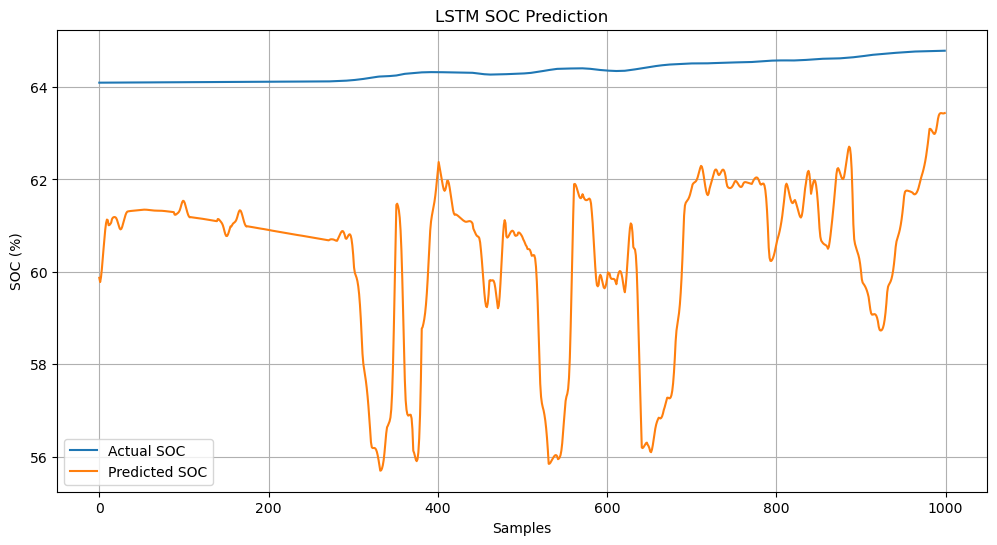

In [36]:
pred = lstm_model.predict(
    X_test_seq[:1000]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test_seq[:1000],
    label="Actual SOC"
)

plt.plot(
    pred,
    label="Predicted SOC"
)

plt.title("LSTM SOC Prediction")
plt.xlabel("Samples")
plt.ylabel("SOC (%)")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test_seq[:1000],
        pred
    )
)

print("RMSE:", rmse)

RMSE: 4.288265209433579


In [38]:
lstm_model.save(
    "LG_HG2_LSTM_SOC.h5"
)

LG HG2 Battery Dataset (NCA Li-ion)

Institution: McMaster University

Objective: SOC Estimation using Deep Learning

### Input Features (X)
Voltage (V)
Current (A)
Temperature (°C)
### Output Target (y)
State of Charge (SOC %)

where Rated Capacity = 3.0 Ah

### Dataset Statistics
Total Samples: 927,095
Training Sequences: 741,646
Testing Sequences: 185,397
Sequence Length: 20
LSTM Architecture
LSTM(64)
Dense(32, ReLU)
Dense(1)
Results
Test Loss (MSE): 3.7629
Test MAE: 1.4702 %
RMSE: 4.2883 %
### Observation
The LSTM model successfully learned the relationship between
Voltage, Current and Temperature for SOC estimation.

Average prediction error remained approximately 1.47%
SOC, indicating good estimation capability.

# GRU

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(64, input_shape=(20,3)),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_gru = gru_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=5,
    batch_size=256
)

Epoch 1/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 110s 36ms/step - loss: 172.3356 - mae: 6.3110 - val_loss: 8.3366 - val_mae: 2.1368
Epoch 2/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 100s 34ms/step - loss: 4.3337 - mae: 1.5161 - val_loss: 6.3959 - val_mae: 1.8808
Epoch 3/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 103s 35ms/step - loss: 3.9451 - mae: 1.4522 - val_loss: 4.2496 - val_mae: 1.5506
Epoch 4/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 101s 35ms/step - loss: 3.6118 - mae: 1.3854 - val_loss: 4.8438 - val_mae: 1.6986
Epoch 5/5
2898/2898 ━━━━━━━━━━━━━━━━━━━━ 103s 35ms/step - loss: 3.2446 - mae: 1.2999 - val_loss: 3.2191 - val_mae: 1.3756


In [41]:
loss_gru, mae_gru = gru_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("GRU Loss:", loss_gru)
print("GRU MAE:", mae_gru)

5794/5794 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 3.2191 - mae: 1.3756
GRU Loss: 3.2190632820129395
GRU MAE: 1.375646948814392


In [42]:
pred_gru = gru_model.predict(
    X_test_seq[:1000]
)

rmse_gru = np.sqrt(
    mean_squared_error(
        y_test_seq[:1000],
        pred_gru
    )
)

print("GRU RMSE:", rmse_gru)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
GRU RMSE: 2.5062243996988443


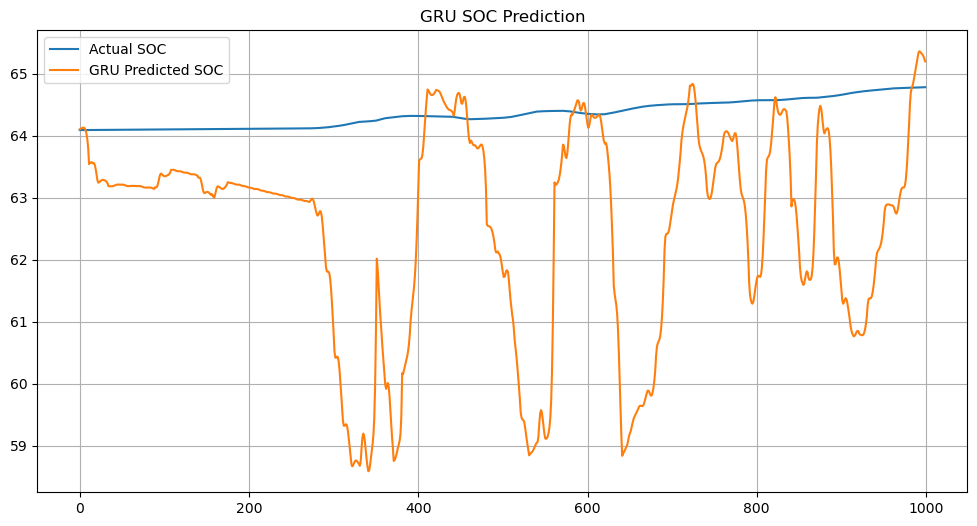

In [43]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_seq[:1000],
    label="Actual SOC"
)

plt.plot(
    pred_gru,
    label="GRU Predicted SOC"
)

plt.legend()
plt.grid(True)
plt.title("GRU SOC Prediction")

plt.show()

### Observation
GRU successfully learned the battery discharge pattern.

Predicted SOC closely follows the actual SOC trend.

Average prediction error is approximately 1.38% SOC.

RMSE of 2.51% indicates good estimation performance.

GRU performed slightly better than LSTM on this dataset.

### GRU vs LSTM

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


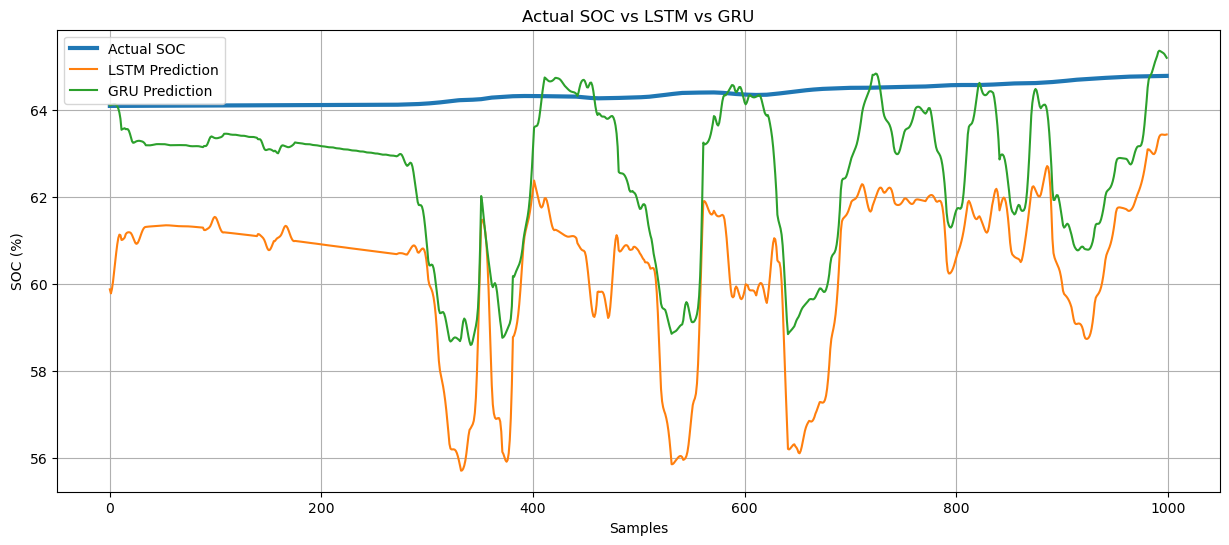

In [44]:
import matplotlib.pyplot as plt

# LSTM predictions
lstm_pred = lstm_model.predict(X_test_seq[:1000]).flatten()

# GRU predictions
gru_pred = gru_model.predict(X_test_seq[:1000]).flatten()

actual = y_test_seq[:1000]

plt.figure(figsize=(15,6))

plt.plot(actual,
         label="Actual SOC",
         linewidth=3)

plt.plot(lstm_pred,
         label="LSTM Prediction")

plt.plot(gru_pred,
         label="GRU Prediction")

plt.title("Actual SOC vs LSTM vs GRU")
plt.xlabel("Samples")
plt.ylabel("SOC (%)")

plt.legend()
plt.grid(True)

plt.show()

### SUMMA